In [ ]:
# 导入数据库
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.sparse.csgraph import minimum_spanning_tree

# 固定随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 输出文件夹
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("随机种子: ", RANDOM_SEED)
print("输出文件夹: ", OUTPUT_DIR.resolve())

随机种子:  42
输出文件夹:  C:\Users\Ran\Desktop\MAV552\ECA\MAV552_ECA_output


In [2]:
# 绘图参数设置
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.sans-serif': ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'], 
    'axes.unicode_minus': False,  
    'figure.titlesize': 16, 
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,      
    'lines.markersize': 8,      
    'figure.dpi': 120,
    'savefig.dpi': 240,
    'savefig.bbox': 'tight'
})

# 颜色（定义调色板，后续按需取用）
COLORS = {
    'primary'  : '#378ADD',   
    'secondary': '#1D9E75',  
    'accent'   : '#D85A30',   
    'neutral'  : '#888780',  
    'palette'  : ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
}

## 1.特征选择与数据预处理

In [3]:
# 1.1 读取数据
fileName = "MAV552_ECA_CustomerSegmentation.csv"
df = pd.read_csv(fileName)

print("Read file:", fileName)
print("Data shape:", df.shape)
display(df.head())

Read file: MAV552_ECA_CustomerSegmentation.csv
Data shape: (2000, 15)


,customer_id,gender,age,marital_status,education_level,monthly_income,num_children,spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month,loyalty_score
0,C100000,Male,32,Married,PhD,5750.0,1.0,550,650,500.0,450,1250.0,1,13,65
1,C100001,Male,38,Married,PhD,8150.0,0.0,500,550,600.0,450,650.0,1,15,52
2,C100002,Female,37,Married,Bachelor,2650.0,1.0,800,150,250.0,300,350.0,2,1,31
3,C100003,Female,46,Married,Bachelor,6900.0,5.0,1100,150,600.0,750,450.0,7,4,46
4,C100004,Male,20,Single,Bachelor,5850.0,0.0,300,600,250.0,800,850.0,2,11,58


#### 数据字典

#### 行为变量（候选的 distance features）
- `spend_grocery`：日常杂货支出
- `spend_fashion`：服饰支出
- `spend_electronics`：电子产品支出
- `spend_dining`：外出就餐支出
- `spend_online`：线上购物支出
- `visits_store_per_month`：线下门店月平均到访次数
- `visits_online_per_month`：线上平台月平均访问次数
#### 只用于画像（profiling，不进入聚类）
- `age`：年龄
- `gender`：性别
- `marital_status`：婚姻状况
- `education_level`：学历
- `monthly_income`：月收入(SGD)
- `num_children`：子女数量
#### 只用于 business validation（用来验证 cluster 是否真的有业务意义）
- `loyalty_score`: 忠诚度评分，由访问次数和消费额决定

In [4]:
# 1.2 数据字典
distanceFeatures = [
    "spend_grocery",
    "spend_fashion",
    "spend_electronics",
    "spend_dining",
    "spend_online",
    "visits_store_per_month",
    "visits_online_per_month",
]

profileOnlyFeatures = [
    "age",
    "gender",
    "marital_status",
    "education_level",
    "monthly_income",
    "num_children",
]

businessValidationFeatures = [
    "loyalty_score",
]

roleTable = pd.DataFrame({
    "feature": distanceFeatures + profileOnlyFeatures + businessValidationFeatures,
    "role": (["distance"] * len(distanceFeatures)
             + ["profile_only"] * len(profileOnlyFeatures)
             + ["business_validation_only"] * len(businessValidationFeatures))
})
display(roleTable)

,feature,role
0,spend_grocery,distance
1,spend_fashion,distance
2,spend_electronics,distance
3,spend_dining,distance
4,spend_online,distance
5,visits_store_per_month,distance
6,visits_online_per_month,distance
7,age,profile_only
8,gender,profile_only
9,marital_status,profile_only


,missingRate
monthly_income,2.5%
num_children,2.5%
spend_electronics,2.5%
spend_online,2.5%
customer_id,0.0%
gender,0.0%
age,0.0%
marital_status,0.0%
education_level,0.0%
spend_grocery,0.0%


,count,mean,std,min,25%,50%,75%,max
spend_grocery,2000.0,699.08,280.87,100.0,500.0,650.0,850.0,1750.0
spend_fashion,2000.0,481.15,263.13,0.0,300.0,450.0,650.0,1500.0
spend_electronics,1950.0,518.82,272.01,0.0,300.0,500.0,700.0,1650.0
spend_dining,2000.0,597.42,267.91,0.0,400.0,600.0,762.5,1700.0
spend_online,1950.0,626.26,345.32,0.0,350.0,600.0,850.0,1850.0
visits_store_per_month,2000.0,4.64,8.64,0.0,2.0,4.0,6.0,100.0
visits_online_per_month,2000.0,8.46,5.10,0.0,4.0,8.0,12.0,29.0


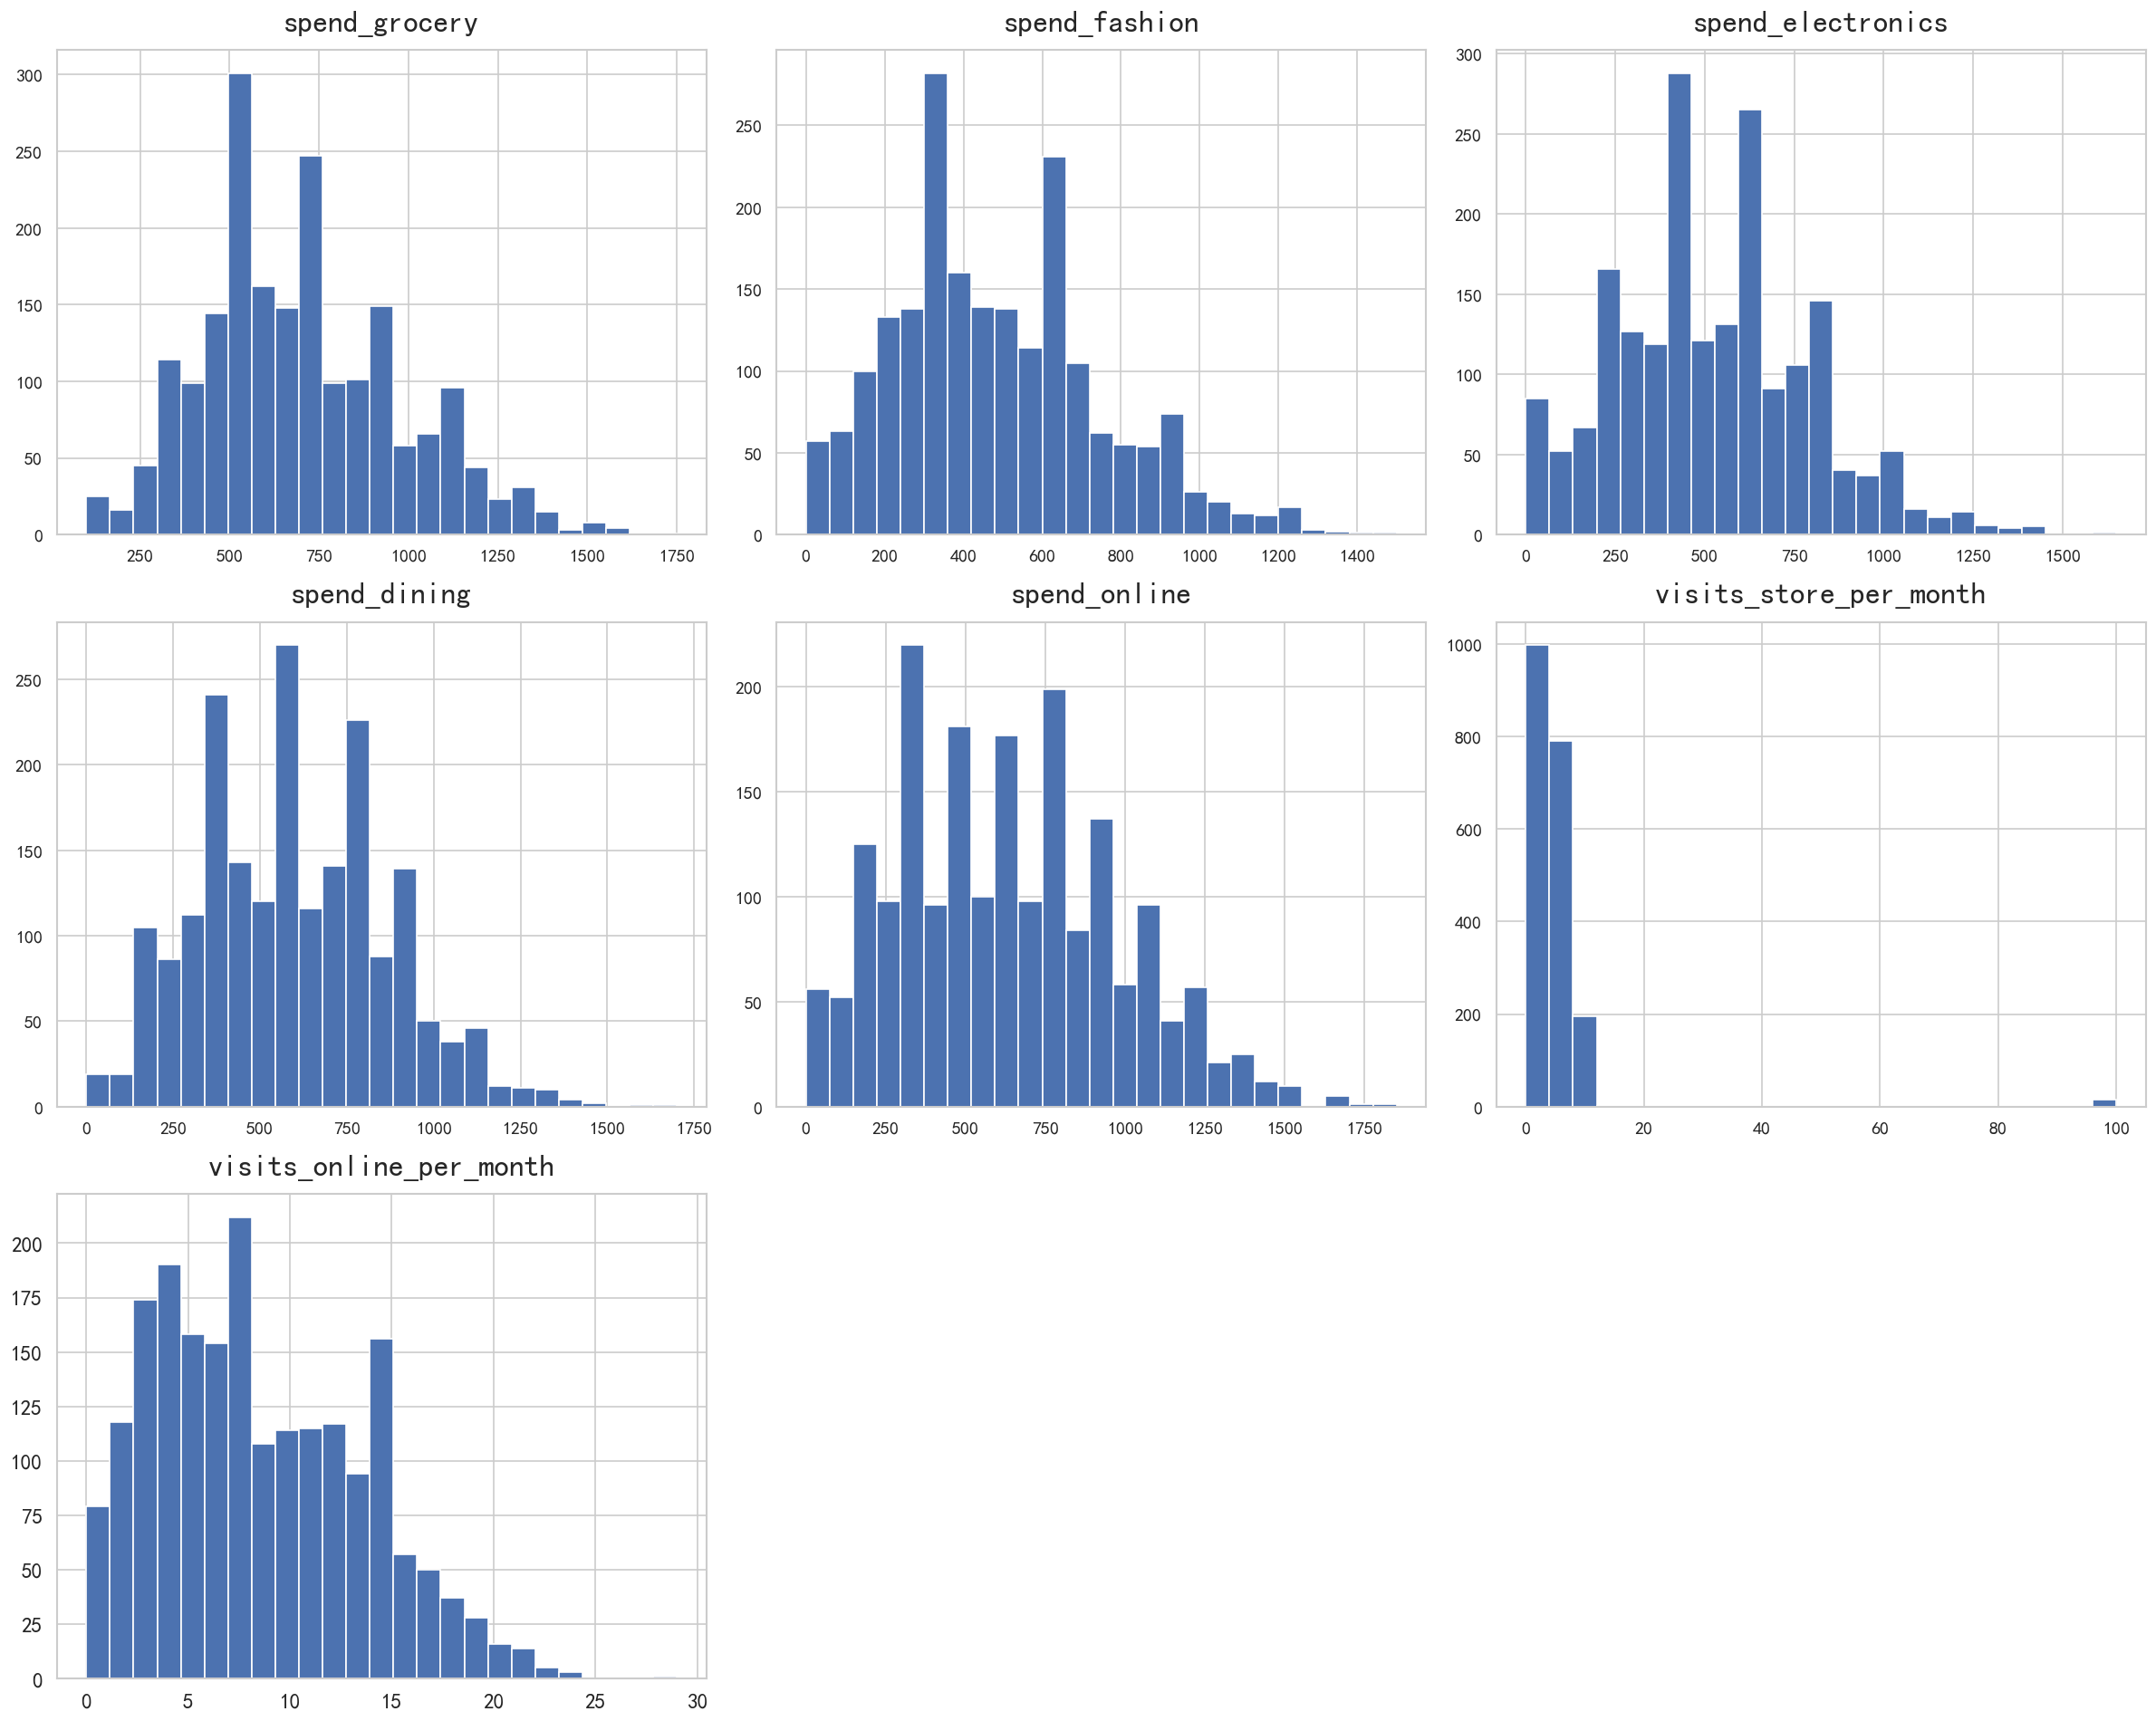

In [5]:
# 1.3 检查数据
#  缺失值检查
missingSummary = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("missingRate")
      .to_frame()
)
display(missingSummary.style.format({"missingRate": "{:.1%}"}))

# 数值变量基本分布情况
display(df[distanceFeatures].describe().T.round(2))

# 数值变量分布可视化
fig, axes = plt.subplots(3, 3, figsize=(20,16))
axes = axes.flatten()

for ax, col in zip(axes, distanceFeatures):
    ax.hist(df[col].dropna(), bins=25)
    ax.set_title(col, fontsize=20, fontweight='bold', pad=12)

ax.tick_params(axis='both', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

for i in range(len(distanceFeatures), len(axes)):
    axes[i].axis('off') 

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Distancefeature Histogram.png')
plt.show()

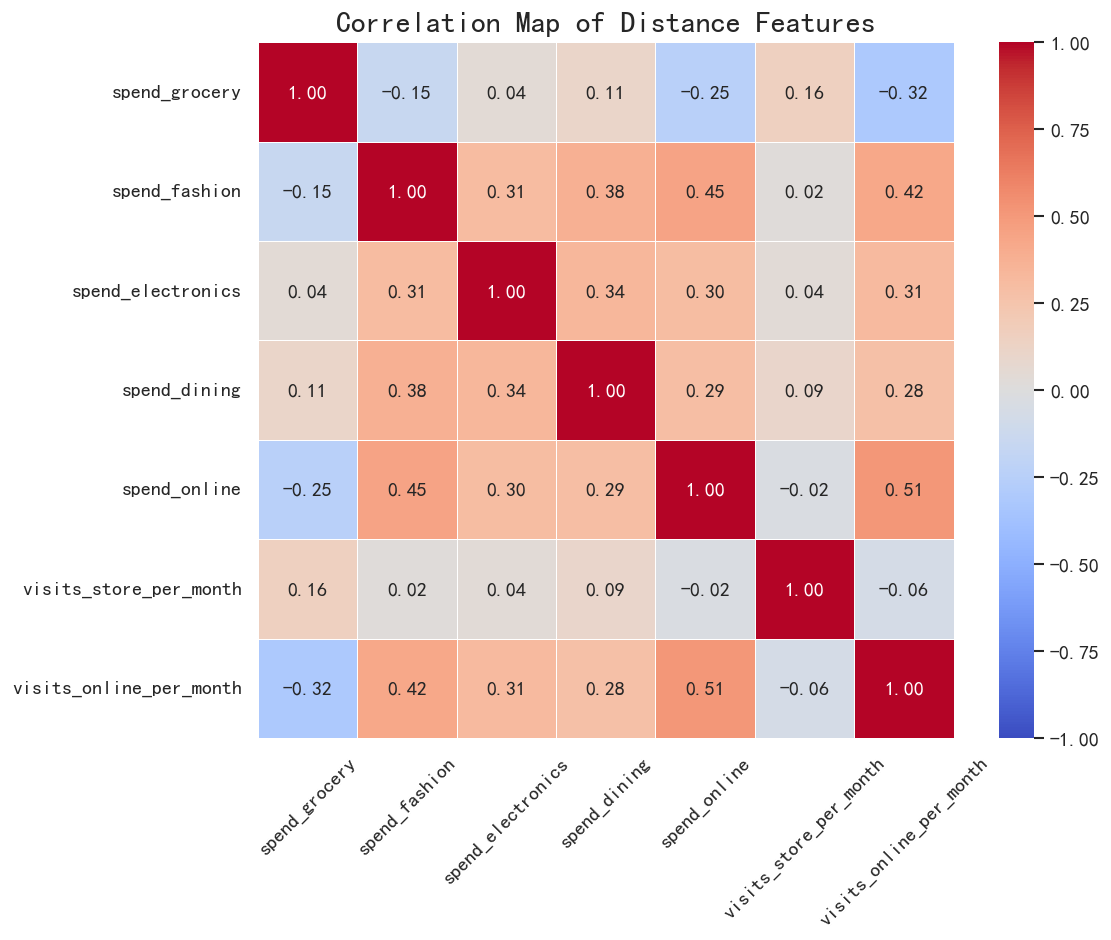

In [6]:
# 1.4 变量之间的相关性分析
corr = df[distanceFeatures].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5)

plt.title("Correlation Map of Distance Features",fontweight='bold',fontsize=18)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Correlation Heatmap.png')
plt.show()

In [7]:
# 1.5 缺失值填充与标准化
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

X = df[distanceFeatures].copy()
XPrepared = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Prepared shape:", XPrepared.shape)

Original shape: (2000, 7)
Prepared shape: (2000, 7)


## 2.PCA降维处理

In [8]:
# 2.1 PCA
pca_full = PCA(random_state=RANDOM_SEED)
pca_scores_full = pca_full.fit_transform(XPrepared)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

n_components_80 = int(np.argmax(cumulative_explained_variance >= 0.80) + 1)
n_components_90 = int(np.argmax(cumulative_explained_variance >= 0.90) + 1)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(explained_variance_ratio) + 1)],
    "explainedVarianceRatio": explained_variance_ratio,
    "cumulativeExplainedVariance": cumulative_explained_variance
})

print("达到 80% 累计解释方差所需 PC 数：", n_components_80)
print("达到 90% 累计解释方差所需 PC 数：", n_components_90)

pca_summary.head(15)

达到 80% 累计解释方差所需 PC 数： 5
达到 90% 累计解释方差所需 PC 数： 6


,PC,explainedVarianceRatio,cumulativeExplainedVariance
0,PC1,0.355524,0.355524
1,PC2,0.191706,0.547230
2,PC3,0.127718,0.674948
3,PC4,0.098555,0.773504
4,PC5,0.080326,0.853829
5,PC6,0.077940,0.931770
6,PC7,0.068230,1.000000


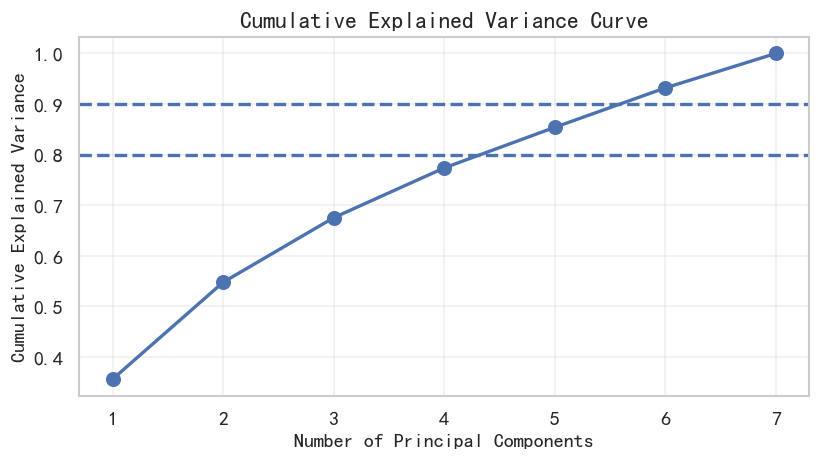

In [9]:
# 2.2 画累计曲线
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Curve")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Cumulative Curve Chart.png')
plt.show()

In [10]:
# 2.3 比较不同PCA维度对聚类的影响
results = []
component_options = [2, 3, 4, 5, 6, 0.80, 0.90]

for n_comp in component_options:
    pca = PCA(n_components=n_comp, random_state=RANDOM_SEED)
    X_pca = pca.fit_transform(XPrepared)
    
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = ((XPrepared - X_reconstructed) ** 2).mean()
    
    # 聚类评估 (统一使用最佳 K=4)
    kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    
    results.append({
        "Method": f"PCA_{n_comp}" if isinstance(n_comp, int) else f"PCA_{int(n_comp*100)}%",
        "Components": pca.n_components_,
        "Expl_Var": round(np.sum(pca.explained_variance_ratio_), 4),
        "MSE": round(mse, 4),
        "Silhouette": round(sil, 4)
    })

comparison_df = pd.DataFrame(results).sort_values(by="Silhouette", ascending=False)
display(comparison_df)


,Method,Components,Expl_Var,MSE,Silhouette
1,PCA_3,3,0.6749,0.3251,0.4475
0,PCA_2,2,0.5472,0.4528,0.4309
2,PCA_4,4,0.7735,0.2265,0.3660
3,PCA_5,5,0.8538,0.1462,0.3212
5,PCA_80%,5,0.8538,0.1462,0.3212
4,PCA_6,6,0.9318,0.0682,0.2462
6,PCA_90%,6,0.9318,0.0682,0.2462


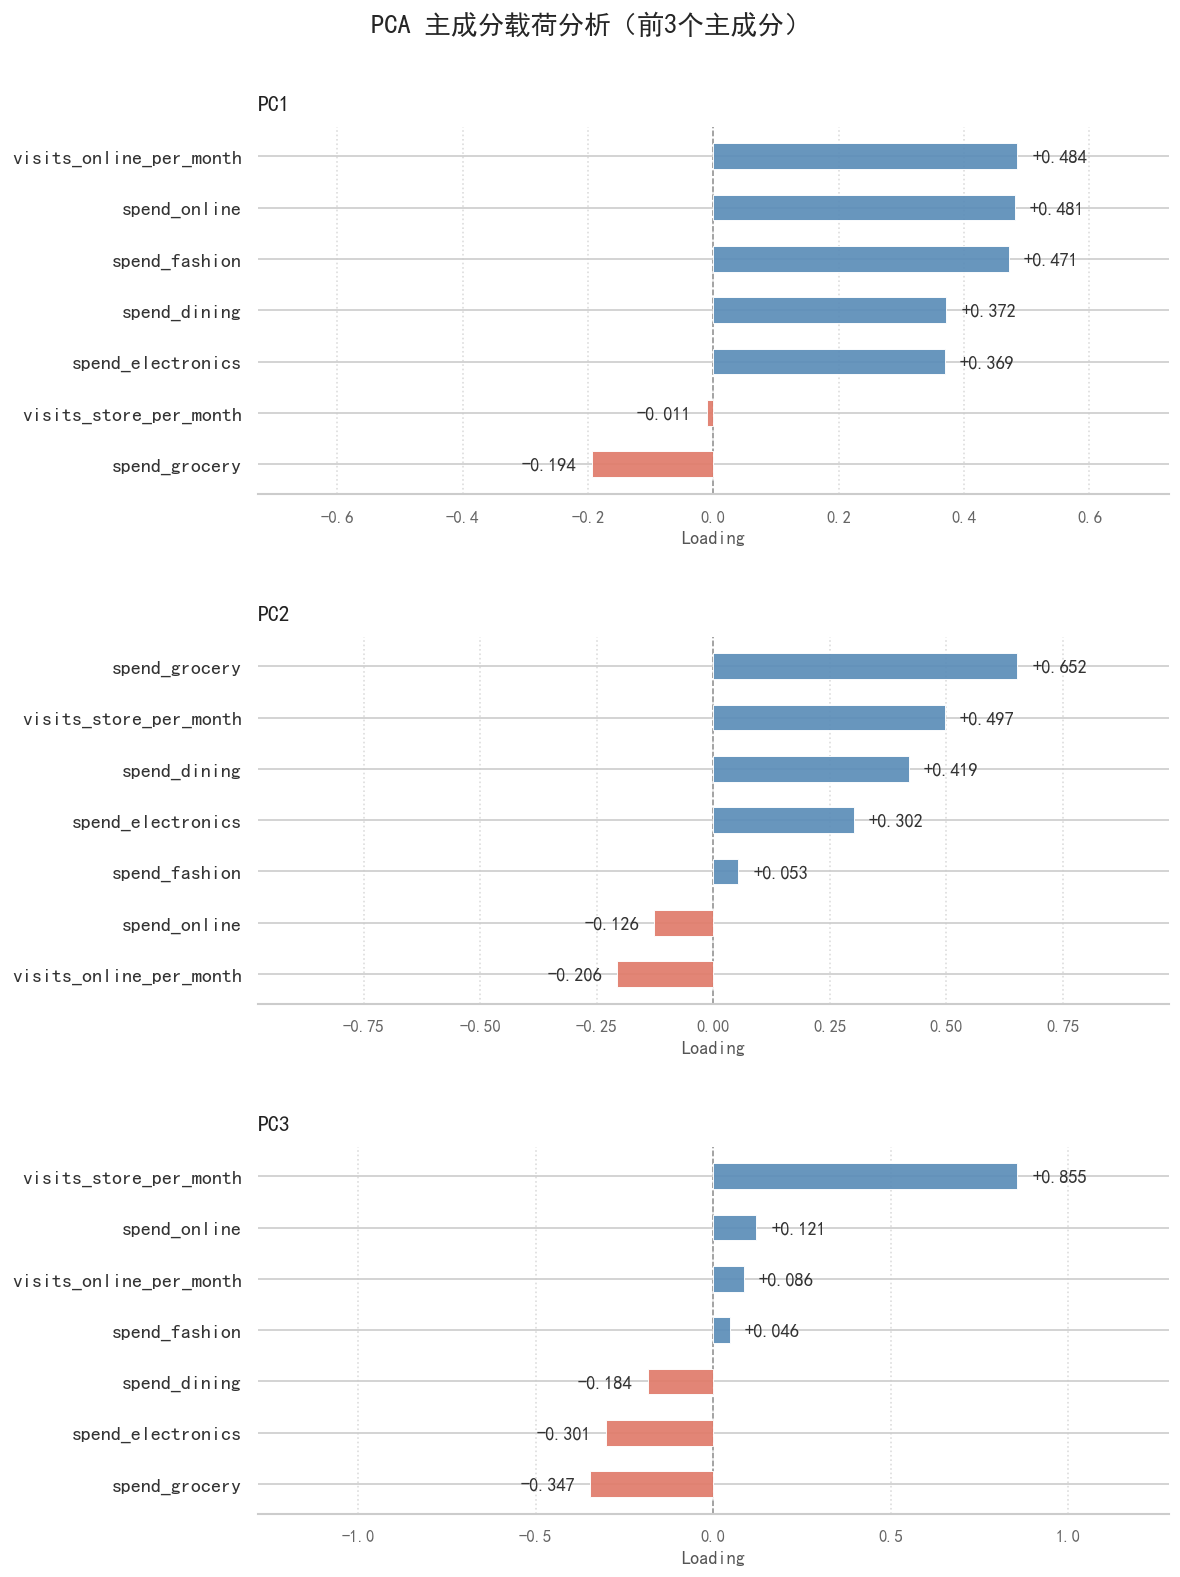

In [11]:
# 2.4 主成分载荷分析
def analyze_pc_loadings(loadings_df, pc_name, top_n=7):
    pc_loadings = loadings_df[pc_name].sort_values(key=abs, ascending=False)
    return pc_loadings.head(top_n)

loadings_df = pd.DataFrame(
    pca_full.components_.T,
    index=distanceFeatures,
    columns=[f"PC{i}" for i in range(1, len(distanceFeatures) + 1)]
)


fig, axes = plt.subplots(3, 1, figsize=(10, 13))
fig.suptitle("PCA 主成分载荷分析（前3个主成分）",
             fontsize=16, fontweight='bold', y=1.01)

for i in range(1, 4):
    pc_name = f"PC{i}"
    ax = axes[i - 1]

    top_features = analyze_pc_loadings(loadings_df, pc_name, top_n=7)
    top_features = top_features.sort_values(ascending=True)

    colors = ['#E07B6A' if x < 0 else '#5B8DB8' for x in top_features.values]

    bars = ax.barh(
        top_features.index,
        top_features.values,
        color=colors,
        edgecolor='white',
        linewidth=0.6,
        height=0.5,
        alpha=0.92
    )

    ax.axvline(0, color='#888888', linewidth=0.9, linestyle='--', zorder=0)

    ax.set_title(
        f"PC{i}",
        fontsize=13, fontweight='bold', pad=10,
        loc='left',color='#222222'
    )

    max_val = top_features.abs().max()
    ax.set_xlim(-max_val * 1.5, max_val * 1.5)
    ax.set_xlabel("Loading", fontsize=11, color='#555555')

    for bar in bars:
        width = bar.get_width()
        offset = max_val * 0.05
        ha = 'left' if width >= 0 else 'right'
        x_pos = width + offset if width >= 0 else width - offset
        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            f'{width:+.3f}',
            va='center', ha=ha,
            fontsize=11, fontweight='bold',
            color='#333333'
        )

    ax.tick_params(axis='y', labelsize=12, colors='#333333')
    ax.tick_params(axis='x', labelsize=10, colors='#666666')
    sns.despine(ax=ax, left=True, bottom=False, top=True, right=True)
    ax.grid(axis='x', linestyle=':', alpha=0.4, color='#aaaaaa')
    ax.set_axisbelow(True)

plt.tight_layout(h_pad=3.0)   
plt.savefig(
    OUTPUT_DIR / 'PCA_Loadings.png',
    dpi=300,                   
    bbox_inches='tight',
    facecolor='white'         
)
plt.show()

方差解释超过80%阈值，保留了数据的主要结构信息，MSE为0.1462信息损失最小，轮廓系数0.333。综合来看PC=5时，信息完整性与聚类质量之间取得最佳平衡

In [12]:
# 2.5 固定保留 5 个主成分
pca_5 = PCA(n_components=5, random_state=RANDOM_SEED)
X_pca_5 = pca_5.fit_transform(XPrepared)

print("聚类输入特征形状:", X_pca_5.shape)

聚类输入特征形状: (2000, 5)


## 3. k-means

In [13]:
# 3.1 K=2到18分别输出各项评估参数
def compute_internal_metrics(X, k_list, random_state=RANDOM_SEED):
    rows = []
    Xd = np.asarray(X)

    for k in k_list:
        km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
        labels = km.fit_predict(Xd)

        rows.append({
            "K": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(
                Xd, labels,
                sample_size=min(500, Xd.shape[0]),
                random_state=random_state
            ),
            "CHI": calinski_harabasz_score(Xd, labels),
            "DBI": davies_bouldin_score(Xd, labels),
            "minClusterRatio": pd.Series(labels).value_counts(normalize=True).min()
        })
    return pd.DataFrame(rows)

k_list = list(range(2, 19))
internal_pca5 = compute_internal_metrics(X_pca_5, k_list)

print(internal_pca5)

     K      inertia  silhouette         CHI       DBI  minClusterRatio
0    2  8212.044284    0.322961  910.327861  1.281840           0.4645
1    3  6401.903167    0.333162  865.899174  0.930192           0.0075
2    4  4958.952635    0.328292  938.462017  0.972956           0.0075
3    5  4231.266436    0.279427  910.252287  1.129367           0.0075
4    6  3749.347715    0.277503  872.647972  1.149644           0.0075
5    7  3484.154709    0.273405  807.450388  1.141490           0.0075
6    8  3268.834515    0.249204  756.061398  1.270735           0.0075
7    9  3108.976278    0.243473  708.030840  1.316904           0.0075
8   10  2964.956825    0.239767  670.330948  1.222974           0.0075
9   11  2845.402703    0.177530  636.684174  1.387042           0.0075
10  12  2730.898553    0.174294  610.347054  1.335071           0.0075
11  13  2626.806895    0.183752  587.924265  1.348781           0.0075
12  14  2536.175093    0.175772  567.269440  1.355611           0.0075
13  15

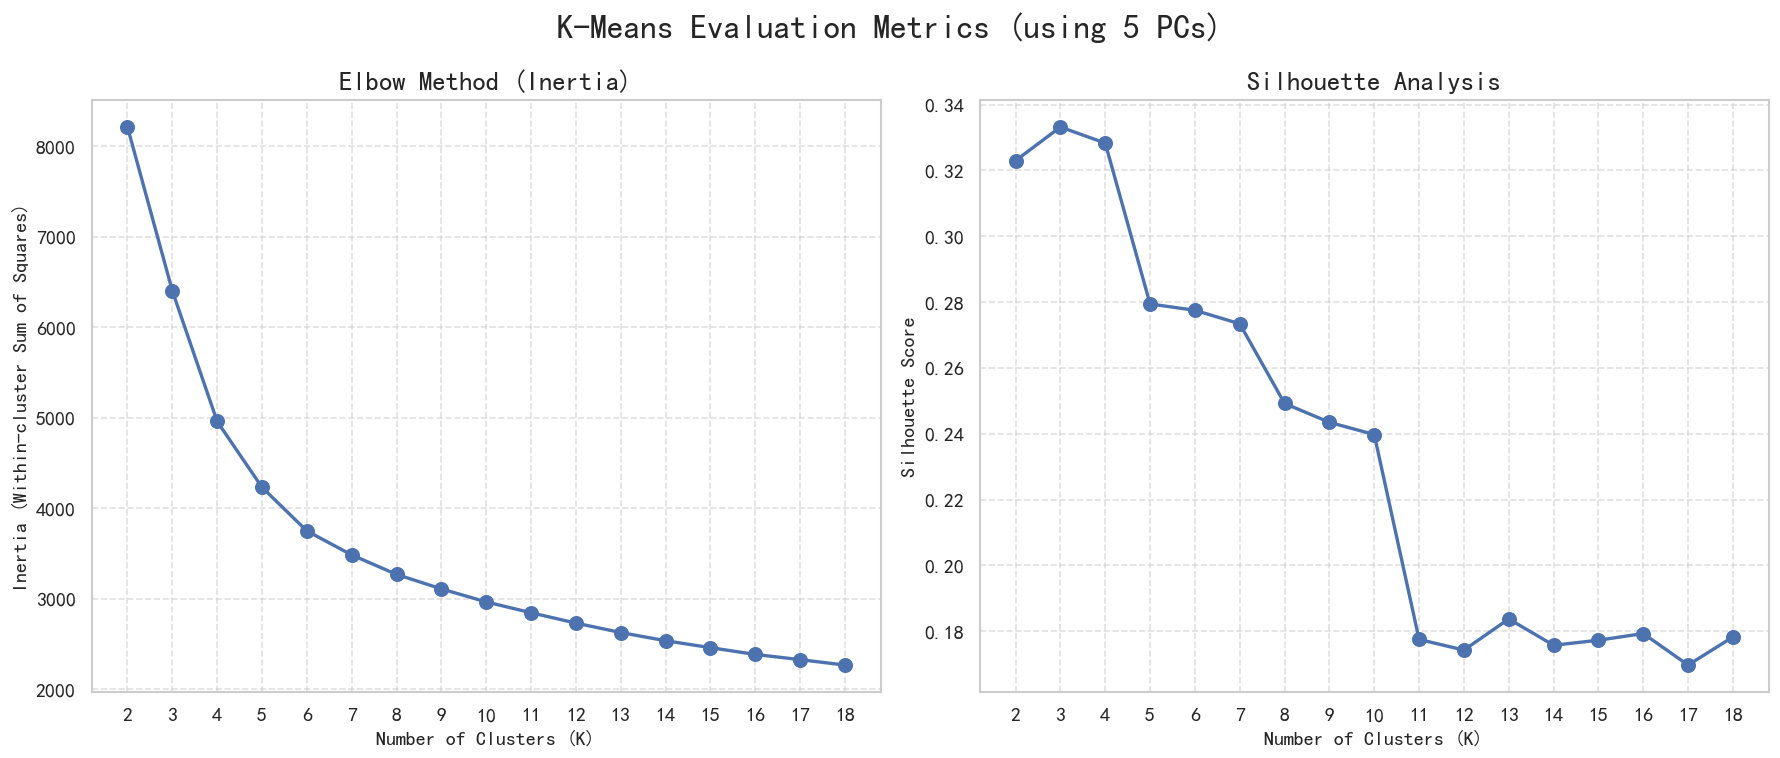

In [14]:
# 3.2 可视化肘部法和轮廓系数
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- 左图：肘部法 (Inertia) ---
ax1.plot(internal_pca5["K"], internal_pca5["inertia"], marker="o")
ax1.set_xlabel('Number of Clusters (K)',)
ax1.set_ylabel('Inertia (Within-cluster Sum of Squares)')
ax1.set_title('Elbow Method (Inertia)',fontsize=16)
ax1.set_xticks(internal_pca5["K"])
ax1.grid(True, linestyle='--',alpha=0.6)

# --- 右图：轮廓系数 (Silhouette Score) ---
ax2.plot(internal_pca5["K"], internal_pca5["silhouette"], marker="o")
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis',fontsize=16)
ax2.set_xticks(internal_pca5["K"])
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle('K-Means Evaluation Metrics (using 5 PCs)', y=1.05, fontweight='bold',fontsize=20)
plt.savefig(OUTPUT_DIR / 'K-Means Evaluation Metrics (using 5 PCs).png')
plt.show()

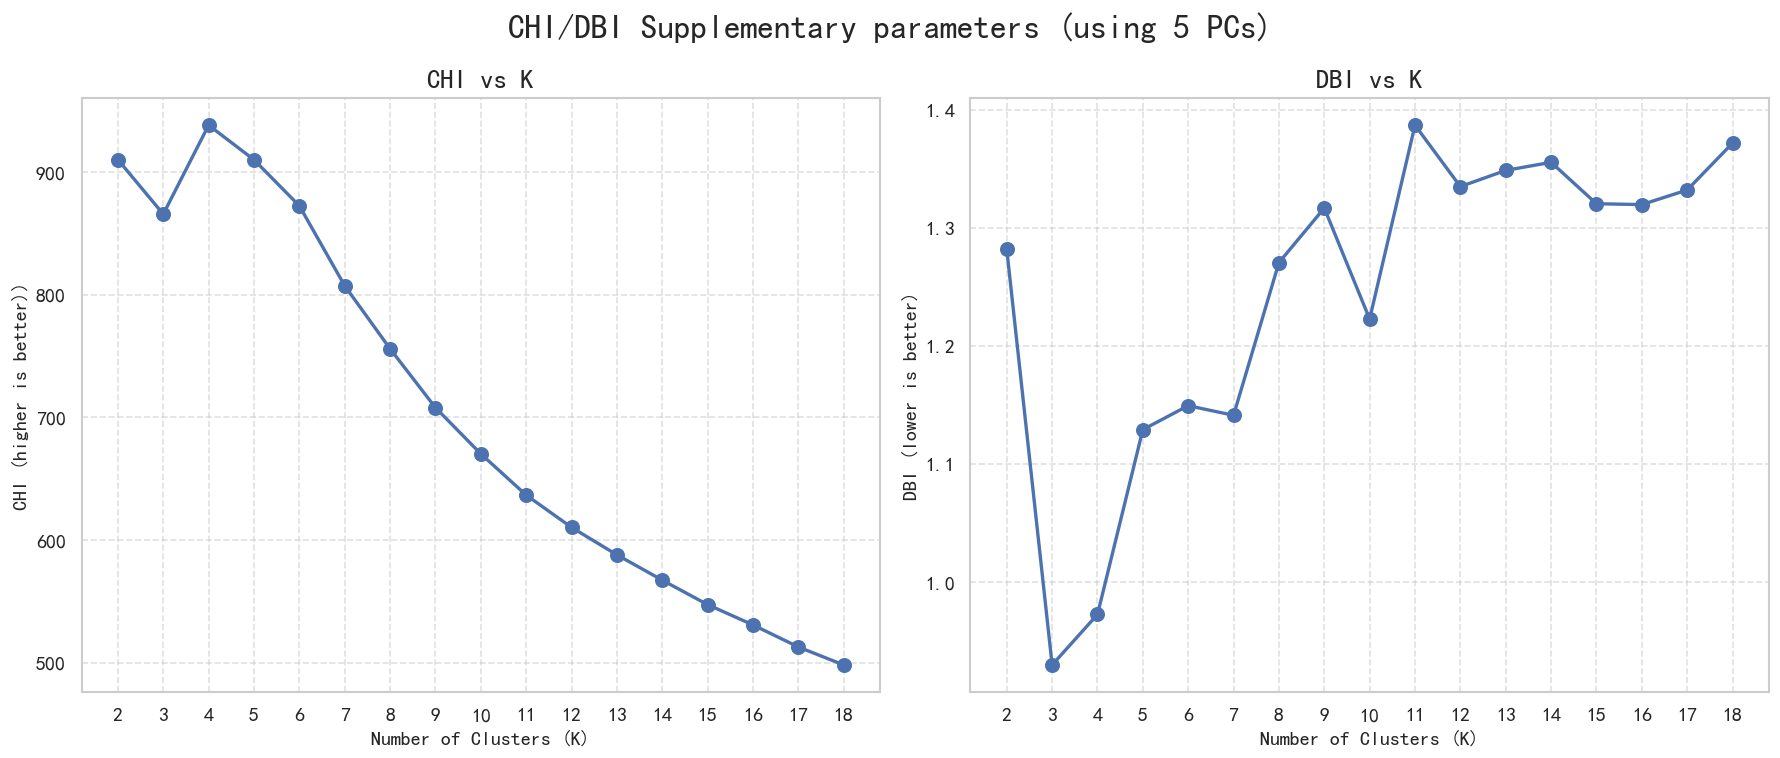

In [15]:
# 3.3 CHI / DBI 两项补充参数
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- 左图：CHI ---
ax1.plot(internal_pca5["K"], internal_pca5["CHI"], marker="o")
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('CHI (higher is better))')
ax1.set_title('CHI vs K',fontsize=16)
ax1.set_xticks(internal_pca5["K"])
ax1.grid(True, linestyle='--',alpha=0.6)

# --- 右图：DBI ---
ax2.plot(internal_pca5["K"], internal_pca5["DBI"], marker="o")
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('DBI (lower is better)')
ax2.set_title('DBI vs K',fontsize=16)
ax2.set_xticks(internal_pca5["K"])
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.suptitle('CHI/DBI Supplementary parameters (using 5 PCs)', y=1.05,fontweight='bold',fontsize=20)
plt.savefig(OUTPUT_DIR / 'K-Means Supplementary Parameters(using 5 PCs).png')
plt.show()

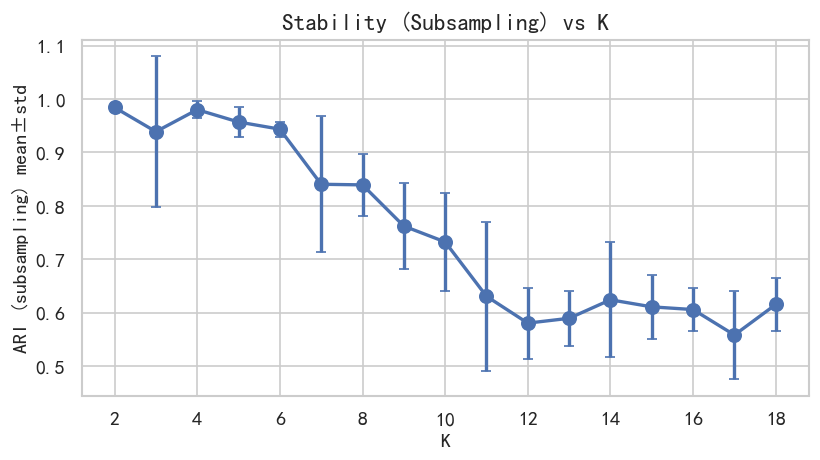

,K,inertia,silhouette,CHI,DBI,minClusterRatio,ARI_mean,ARI_std,NMI_mean,NMI_std,ARI_init_mean,ARI_init_std,NMI_init_mean,NMI_init_std
0,2,8212.044284,0.322961,910.327861,1.281840,0.4645,0.984072,0.008400,0.965798,0.016698,0.988434,0.005102,0.974738,1.028200e-02
1,3,6401.903167,0.333162,865.899174,0.930192,0.0075,0.938731,0.141957,0.926815,0.134138,0.521864,0.000000,0.528373,8.599751e-17
2,4,4958.952635,0.328292,938.462017,0.972956,0.0075,0.979951,0.015478,0.970641,0.019382,0.802434,0.160743,0.833605,1.358383e-01
3,5,4231.266436,0.279427,910.252287,1.129367,0.0075,0.956823,0.028986,0.941475,0.031823,0.796845,0.165390,0.828860,1.330456e-01
4,6,3749.347715,0.277503,872.647972,1.149644,0.0075,0.943395,0.014280,0.930444,0.014483,0.902840,0.152876,0.911998,1.209055e-01
5,7,3484.154709,0.273405,807.450388,1.141490,0.0075,0.840235,0.127787,0.843696,0.102782,0.858173,0.119606,0.859815,1.058014e-01
6,8,3268.834515,0.249204,756.061398,1.270735,0.0075,0.839070,0.058312,0.843074,0.050047,0.687020,0.080018,0.745772,4.723920e-02
7,9,3108.976278,0.243473,708.030840,1.316904,0.0075,0.761910,0.080973,0.776138,0.065007,0.609021,0.111682,0.703293,6.196166e-02
8,10,2964.956825,0.239767,670.330948,1.222974,0.0075,0.732219,0.091468,0.755910,0.057944,0.550976,0.028886,0.650392,2.242052e-02
9,11,2845.402703,0.177530,636.684174,1.387042,0.0075,0.630458,0.139105,0.734387,0.084901,0.518632,0.058881,0.669296,3.140542e-02


In [16]:
# 3.4 数据扰动稳定性平均值和标准差计算
def compute_full_metrics(X, k_list, random_state=RANDOM_SEED):
    rows = []
    Xd = np.asarray(X)
    n_samples = Xd.shape[0]

    for k in k_list:
        km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
        labels = km.fit_predict(Xd)
        
        row = {
            "K": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(Xd, labels, sample_size=min(500, n_samples), random_state=RANDOM_SEED),
            "CHI": calinski_harabasz_score(Xd, labels),
            "DBI": davies_bouldin_score(Xd, labels),
            "minClusterRatio": pd.Series(labels).value_counts(normalize=True).min()
        }

        runs = 10
        frac = 0.8
        ari_sub_list, nmi_sub_list = [], []
        idx_all = np.arange(n_samples)
        
        for r in range(runs):
            rs = random_state + r
            state = np.random.RandomState(rs)
            idx_sub = state.choice(idx_all, size=int(n_samples * frac), replace=False)
            
            km_sub = KMeans(n_clusters=k, n_init=10, random_state=rs)
            labels_sub = km_sub.fit_predict(Xd[idx_sub])
            
            ari_sub_list.append(adjusted_rand_score(labels[idx_sub], labels_sub))
            nmi_sub_list.append(normalized_mutual_info_score(labels[idx_sub], labels_sub))
        
        row["ARI_mean"] = np.mean(ari_sub_list)
        row["ARI_std"] = np.std(ari_sub_list)
        row["NMI_mean"] = np.mean(nmi_sub_list)
        row["NMI_std"] = np.std(nmi_sub_list)

        ari_init_list, nmi_init_list = [], []
        for r in range(1, 6): 
            rs = random_state + r + 100
            km_init = KMeans(n_clusters=k, n_init=1, random_state=rs) 
            labels_init = km_init.fit_predict(Xd)
            
            ari_init_list.append(adjusted_rand_score(labels, labels_init))
            nmi_init_list.append(normalized_mutual_info_score(labels, labels_init))
        
        row["ARI_init_mean"] = np.mean(ari_init_list)
        row["ARI_init_std"] = np.std(ari_init_list)
        row["NMI_init_mean"] = np.mean(nmi_init_list)
        row["NMI_init_std"] = np.std(nmi_init_list)

        rows.append(row)
        
    return pd.DataFrame(rows)

stability_df = compute_full_metrics(X_pca_5, k_list=range(2, 19))

# 画图
plt.figure(figsize=(7, 4))
plt.errorbar(stability_df["K"], stability_df["ARI_mean"], yerr=stability_df["ARI_std"], marker="o", capsize=3)
plt.xlabel("K"); plt.ylabel("ARI (subsampling) mean±std")
plt.title("Stability (Subsampling) vs K")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Stability of K-Means.png')
plt.show()

display(stability_df)


============================== K=3 聚类详细分析 ==============================

[K=3 簇规模分布]:


,数量(n),占比(share)
Cluster_Labels_K3,,
0,913,0.456
1,1072,0.536
2,15,0.008


[K=3 各簇原始特征均值对比]:


,spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month
Cluster_Labels_K3,,,,,,,
0,824.205915,311.555312,386.753100,474.753560,377.283766,4.388828,4.395400
1,591.511194,625.373134,630.916031,701.585821,836.511725,3.513993,11.927239
2,770.000000,496.666667,496.666667,620.000000,646.428571,100.000000,8.200000



============================== K=4 聚类详细分析 ==============================

[K=4 簇规模分布]:


,数量(n),占比(share)
Cluster_Labels_K4,,
0,628,0.314
1,466,0.233
2,891,0.446
3,15,0.008


[K=4 各簇原始特征均值对比]:


,spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month
Cluster_Labels_K4,,,,,,,
0,990.923567,444.267516,586.683007,716.799363,526.113180,5.979299,6.286624
1,629.184549,228.218884,263.105727,321.244635,277.184279,2.894850,3.508584
2,528.731762,639.169473,605.005754,657.351291,879.277153,2.996633,12.588103
3,770.000000,496.666667,496.666667,620.000000,646.428571,100.000000,8.200000


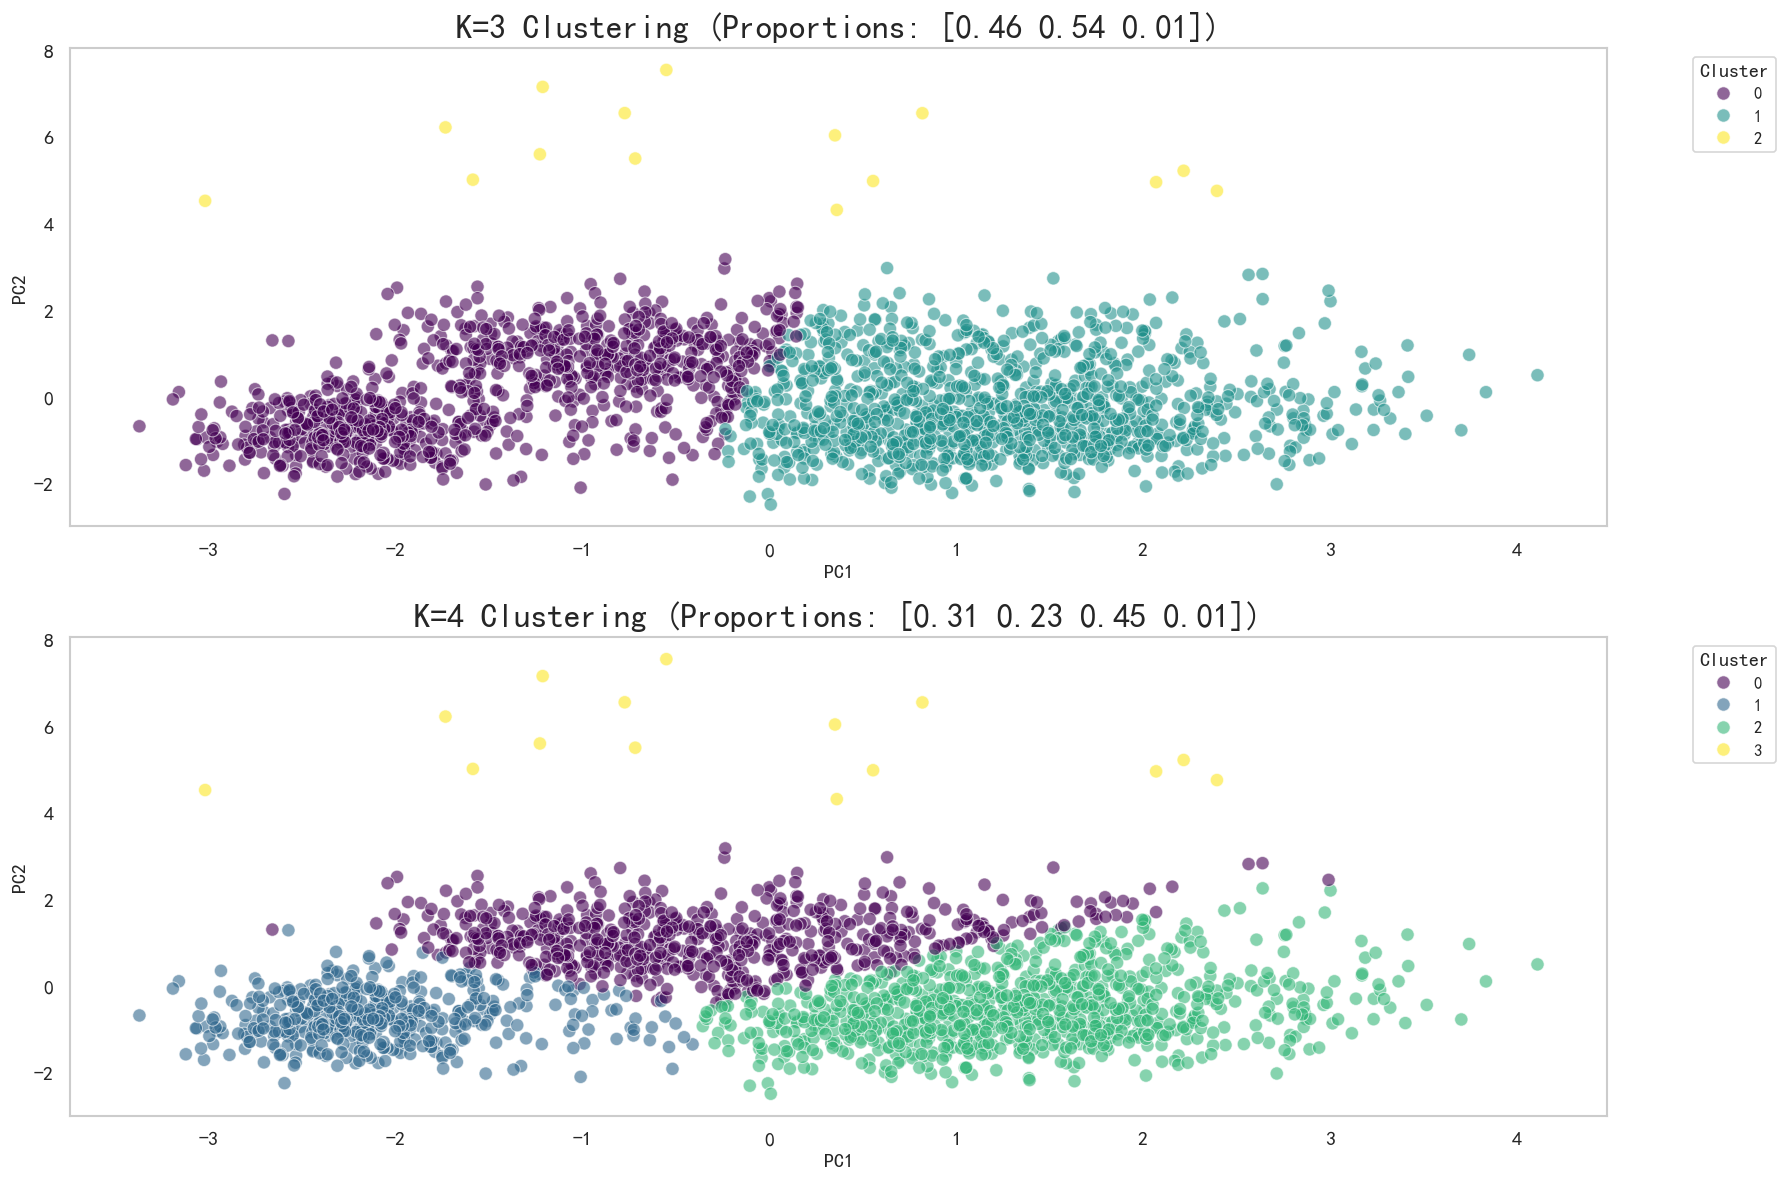

In [17]:
# 3.5 对比 k=3 和 k=4
compare_ks = [3, 4]
fig, axes = plt.subplots(len(compare_ks), 1, figsize=(15, 10)) 

for i, k in enumerate(compare_ks):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_pca_5)
    
    col_name = f'Cluster_Labels_K{k}'
    df[col_name] = labels
    
    print(f"\n" + "="*30 + f" K={k} 聚类详细分析 " + "="*30)
    
    size_info = pd.DataFrame({
        "数量(n)": df[col_name].value_counts().sort_index(),
        "占比(share)": df[col_name].value_counts(normalize=True).sort_index().round(3)
    })
    print(f"\n[K={k} 簇规模分布]:")
    display(size_info)
    
    cluster_avg = df.groupby(col_name)[distanceFeatures].mean()
    print(f"[K={k} 各簇原始特征均值对比]:")
    display(cluster_avg)
   
    temp_df = pd.DataFrame(X_pca_5, columns=[f'PC{j+1}' for j in range(5)])
    temp_df['Cluster'] = labels
    counts = temp_df['Cluster'].value_counts(normalize=True).sort_index()
    
    sns.scatterplot(data=temp_df, x='PC1', y='PC2', hue='Cluster', 
                    palette='viridis', ax=axes[i], alpha=0.6)
    axes[i].grid(False) 
    axes[i].set_title(f'K={k} Clustering (Proportions: {counts.values.round(2)})',fontweight='bold',fontsize=20)
    axes[i].legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'PCA_KMeans_Clustering_Comparison.png')
plt.show()

In [18]:
# 3.6 运行最终聚类模型 k=4 
final_k = 4
km_final = KMeans(n_clusters=final_k, n_init=20, random_state=RANDOM_SEED)

labels_k4 = km_final.fit_predict(X_pca_5)

df['Cluster_Labels_K4'] = labels_k4

display(df.head())

,customer_id,gender,age,marital_status,education_level,monthly_income,num_children,spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month,loyalty_score,Cluster_Labels_K3,Cluster_Labels_K4
0,C100000,Male,32,Married,PhD,5750.0,1.0,550,650,500.0,450,1250.0,1,13,65,1,2
1,C100001,Male,38,Married,PhD,8150.0,0.0,500,550,600.0,450,650.0,1,15,52,1,2
2,C100002,Female,37,Married,Bachelor,2650.0,1.0,800,150,250.0,300,350.0,2,1,31,0,1
3,C100003,Female,46,Married,Bachelor,6900.0,5.0,1100,150,600.0,750,450.0,7,4,46,0,0
4,C100004,Male,20,Single,Bachelor,5850.0,0.0,300,600,250.0,800,850.0,2,11,58,1,2


## 4. 层次聚类

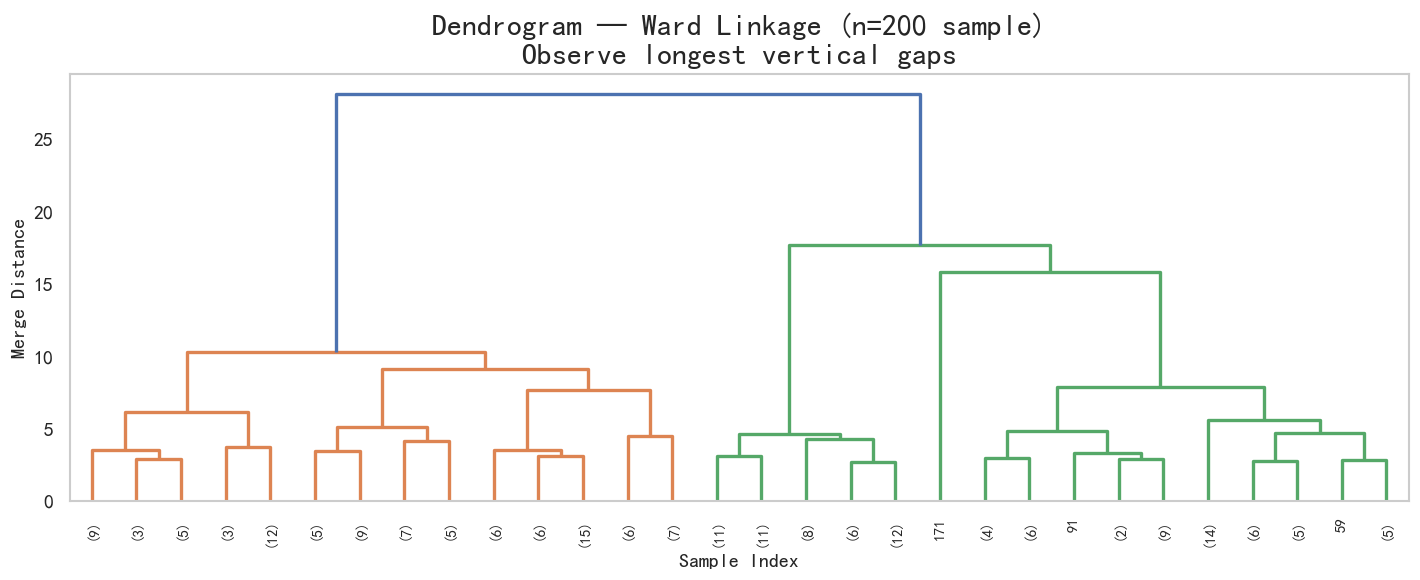

In [19]:
#  4.1 建模，画树状图 
Z_full = linkage(X_pca_5, method='ward')

np.random.seed(RANDOM_SEED)
sample_idx = np.random.choice(len(X_pca_5), size=200, replace=False)
Z_sample = linkage(X_pca_5[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z_sample, ax=ax,
    truncate_mode='lastp', p=30,
    color_threshold=None,         
    leaf_rotation=90, leaf_font_size=9
)
ax.grid(False) 
ax.set_title("Dendrogram — Ward Linkage (n=200 sample)\nObserve longest vertical gaps",fontweight='bold',fontsize=18)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Merge Distance")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Dendrogram.png')
plt.show()

In [20]:
# 4.2 查看最长垂直线段切割情况
merge_distances = Z_full[:, 2]
gaps = np.diff(merge_distances)
# 最大gap对应的位置 → 建议的切割点
top_gaps = np.argsort(gaps)[::-1][:5]
print("最大合并距离跳跃（建议切割位置）:")
for i in top_gaps:
    n_clusters_at_cut = len(merge_distances) - i  
    print(f"  gap={gaps[i]:.3f}  → 切割后约 {n_clusters_at_cut} 簇")

最大合并距离跳跃（建议切割位置）:
  gap=23.349  → 切割后约 2 簇
  gap=15.098  → 切割后约 4 簇
  gap=8.526  → 切割后约 3 簇
  gap=8.230  → 切割后约 6 簇
  gap=5.950  → 切割后约 5 簇


In [21]:
# 4.3 计算层次聚类评估指标
def evaluateHierarchicalRange(X, ks=range(2, 9), n_iterations=10):
    """
    计算层次聚类评估指标，新增稳定性(Stability)扰动计算
    """
    results = []
    Z = linkage(X, method='ward')
    orig_dists = pdist(X)
    coph_corr, _ = cophenet(Z, orig_dists)
    
    for k in ks:
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels_full = model.fit_predict(X)
        
        sil = silhouette_score(X, labels_full)
        chi = calinski_harabasz_score(X, labels_full)
        dbi = davies_bouldin_score(X, labels_full)
        
        counts = pd.Series(labels_full).value_counts()
        min_ratio = counts.min() / counts.mean()
        
        stability_scores = []
        for i in range(n_iterations):
            sample_indices = np.random.choice(len(X), size=int(0.9 * len(X)), replace=False)
            X_sample = X[sample_indices]
            
            labels_sample = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_sample)
            
            ari = adjusted_rand_score(labels_full[sample_indices], labels_sample)
            stability_scores.append(ari)
        
        avg_stability = np.mean(stability_scores)
        
        results.append({
            "k": k,
            "silhouette": sil,
            "DBI": dbi,
            "CHI": chi,
            "copheneticCorr": coph_corr,
            "minClusterRatio": min_ratio,
            "stability": avg_stability  
        })
    
    return pd.DataFrame(results)

hierResults = evaluateHierarchicalRange(X_pca_5, ks=range(2, 9))

rankDf = hierResults.copy()
rankDf["silRank"] = rankDf["silhouette"].rank(ascending=False, method="min")
rankDf["dbiRank"] = rankDf["DBI"].rank(ascending=True, method="min")
rankDf["chiRank"] = rankDf["CHI"].rank(ascending=False, method="min")
rankDf["cophRank"] = rankDf["copheneticCorr"].rank(ascending=False, method="min")
rankDf["minRatioRank"] = rankDf["minClusterRatio"].rank(ascending=False, method="min")
rankDf["stabilityRank"] = rankDf["stability"].rank(ascending=False, method="min") 

rankDf["avgRank"] = rankDf[
    ["silRank", "dbiRank", "chiRank", "cophRank", "minRatioRank", "stabilityRank"]
].mean(axis=1)

print("\n===== Hierarchical Clustering Evaluation Metrics (with Stability) =====")
display(hierResults.round(4))

print("\n综合排名结果：")
display(rankDf.sort_values("avgRank"))


===== Hierarchical Clustering Evaluation Metrics (with Stability) =====


,k,silhouette,DBI,CHI,copheneticCorr,minClusterRatio,stability
0,2,0.3076,1.3468,832.3044,0.4845,0.9240,0.4762
1,3,0.3179,0.9672,807.6411,0.4845,0.0225,0.6776
2,4,0.3001,0.9676,847.2949,0.4845,0.0300,0.6868
3,5,0.2651,1.0800,803.5411,0.4845,0.0375,0.7355
4,6,0.2437,1.2002,763.9559,0.4845,0.0450,0.6138
5,7,0.2304,1.4141,701.2183,0.4845,0.0525,0.5896
6,8,0.2114,1.4542,657.0973,0.4845,0.0600,0.5469



综合排名结果：


,k,silhouette,DBI,CHI,copheneticCorr,minClusterRatio,stability,silRank,dbiRank,chiRank,cophRank,minRatioRank,stabilityRank,avgRank
2,4,0.300101,0.967612,847.294937,0.484469,0.0300,0.686782,3.0,2.0,1.0,1.0,6.0,2.0,2.500000
1,3,0.317891,0.967215,807.641066,0.484469,0.0225,0.677614,1.0,1.0,3.0,1.0,7.0,3.0,2.666667
0,2,0.307605,1.346754,832.304442,0.484469,0.9240,0.476213,2.0,5.0,2.0,1.0,1.0,7.0,3.000000
3,5,0.265060,1.080035,803.541057,0.484469,0.0375,0.735526,4.0,3.0,4.0,1.0,5.0,1.0,3.000000
4,6,0.243711,1.200231,763.955916,0.484469,0.0450,0.613806,5.0,4.0,5.0,1.0,4.0,4.0,3.833333
5,7,0.230375,1.414064,701.218264,0.484469,0.0525,0.589599,6.0,6.0,6.0,1.0,3.0,5.0,4.500000
6,8,0.211429,1.454181,657.097252,0.484469,0.0600,0.546896,7.0,7.0,7.0,1.0,2.0,6.0,5.000000


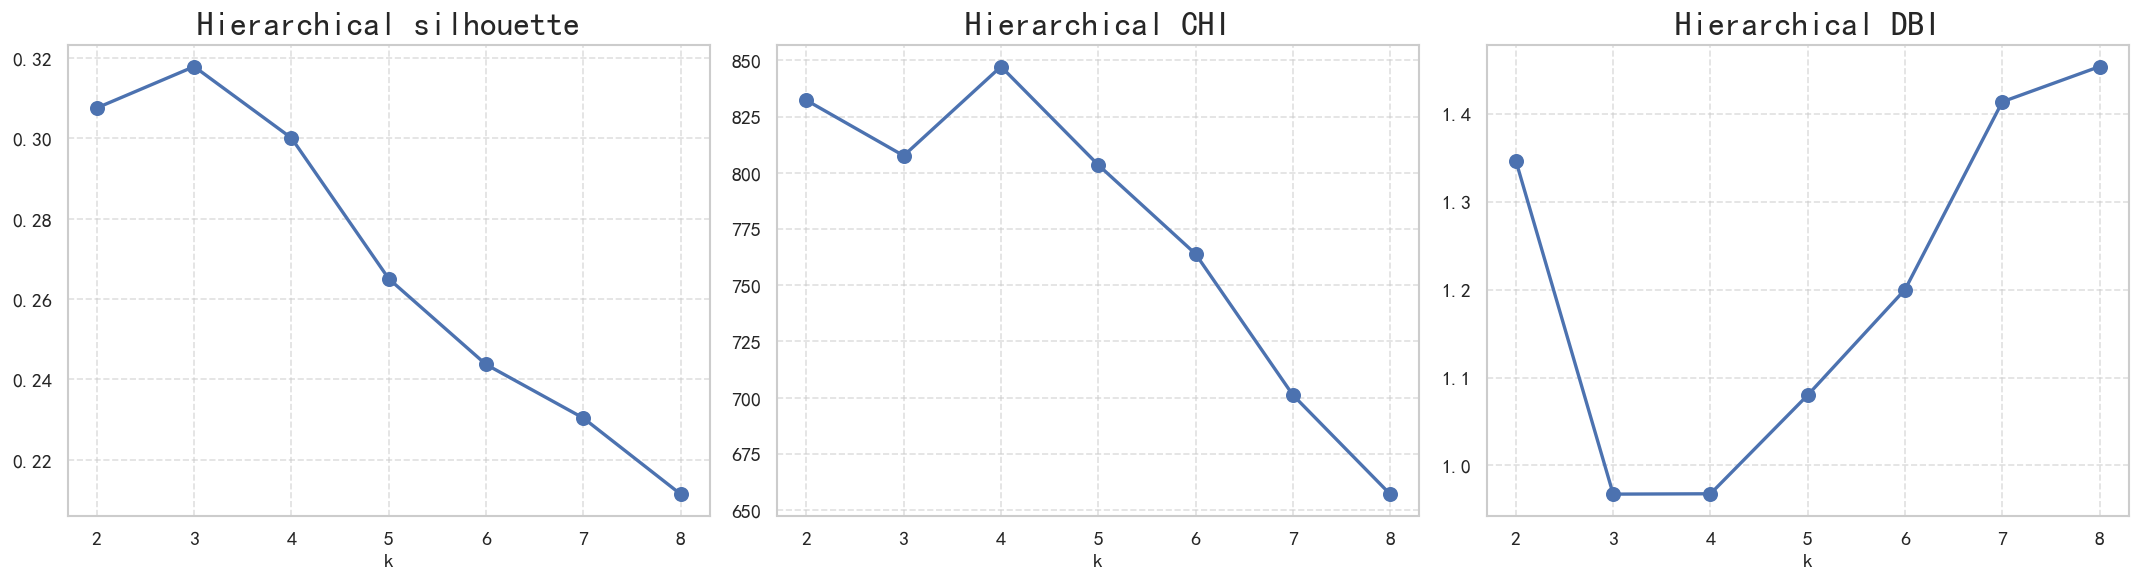

In [22]:
# 4.4 绘制评估指标图 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1: Silhouette Score
axes[0].plot(hierResults["k"], hierResults["silhouette"], marker="o")
axes[0].set_title("Hierarchical silhouette",fontweight='bold',fontsize=20)
axes[0].set_xlabel("k")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 图 2: CHI
axes[1].plot(hierResults["k"], hierResults["CHI"], marker="o")
axes[1].set_title("Hierarchical CHI",fontweight='bold',fontsize=20)
axes[1].set_xlabel("k")
axes[1].grid(True, linestyle='--', alpha=0.6)

# 图 3: DBI
axes[2].plot(hierResults["k"], hierResults["DBI"], marker="o")
axes[2].set_title("Hierarchical DBI",fontweight='bold',fontsize=20)
axes[2].set_xlabel("k")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Hierarchical_Clustering_Evaluation_Metrics.png')
plt.show()

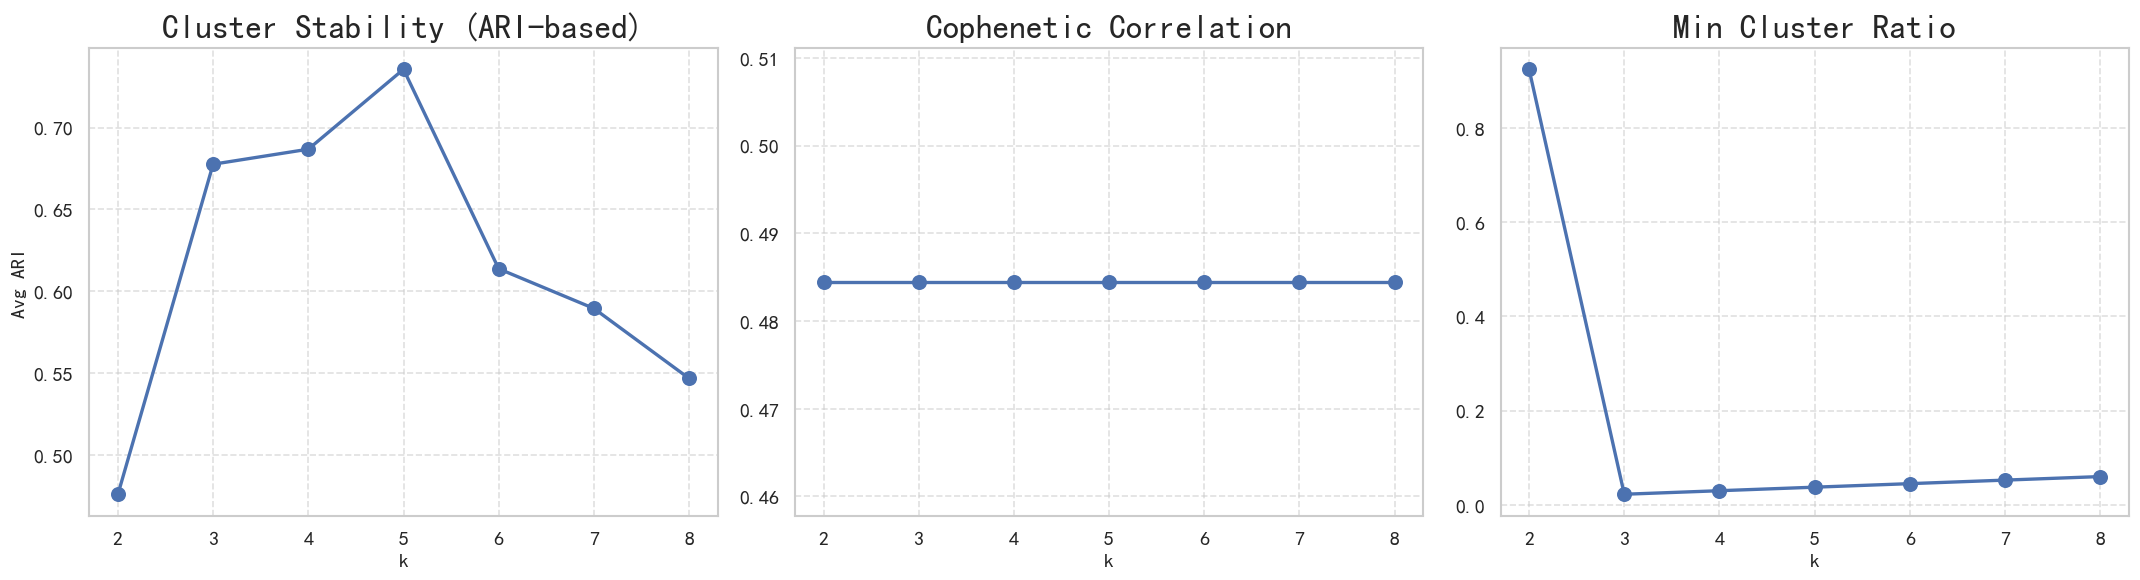

In [23]:
# 4.5 绘制评估指标图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1: Stability (由扰动计算出的 ARI 均值，越高越好)
axes[0].plot(hierResults["k"], hierResults["stability"], marker="o")
axes[0].set_title("Cluster Stability (ARI-based)",fontweight='bold',fontsize=20)
axes[0].set_xlabel("k")
axes[0].set_ylabel("Avg ARI")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 图 2: Cophenetic Correlation (衡量层级树保留原始距离的程度，越高越好)
axes[1].plot(hierResults["k"], hierResults["copheneticCorr"], marker="o")
axes[1].set_title("Cophenetic Correlation",fontweight='bold',fontsize=20)
axes[1].set_xlabel("k")
axes[1].grid(True, linestyle='--', alpha=0.6)

# 图 3: Cluster Ratio (最小簇与平均规模之比，越高说明簇分布越均匀)
axes[2].plot(hierResults["k"], hierResults["minClusterRatio"], marker="o")
axes[2].set_title("Min Cluster Ratio",fontweight='bold',fontsize=20)
axes[2].set_xlabel("k")
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Hierarchical_Clustering_Evaluation_Metrics2.png')
plt.show()

In [24]:
# 4.6 自动选出最优K
bestRow = rankDf.sort_values("avgRank").iloc[0]

chosenK = int(bestRow["k"])

print("自动选出的候选最优 k：", chosenK)
display(bestRow.to_frame().T)

自动选出的候选最优 k： 4


,k,silhouette,DBI,CHI,copheneticCorr,minClusterRatio,stability,silRank,dbiRank,chiRank,cophRank,minRatioRank,stabilityRank,avgRank
2,4.0,0.300101,0.967612,847.294937,0.484469,0.03,0.686782,3.0,2.0,1.0,1.0,6.0,2.0,2.5


In [25]:
# 4.7 切割树状图
K_final_hier = int(bestRow["k"])
print(f"层次聚类最终选择 K = {K_final_hier}（来自树状图 + 综合评估指标）")
labels_hier = fcluster(Z_full, t=K_final_hier, criterion="maxclust")

labels_hier = labels_hier - 1
df['Hier_Cluster_Labels'] = labels_hier

size_hier = df['Hier_Cluster_Labels'].value_counts().sort_index()
share_hier = (size_hier / len(df)).round(3)
cluster_size_hier = pd.DataFrame({
    "n": size_hier, 
    "share": share_hier
})

cluster_summary_hier = df.groupby('Hier_Cluster_Labels')[distanceFeatures].mean()

print(f"===== 层次聚类最终结果 (K={K_final_hier}) =====")
display(cluster_size_hier)

print("\n===== 层次聚类各簇特征均值对比 =====")
display(cluster_summary_hier.round(1))

层次聚类最终选择 K = 4（来自树状图 + 综合评估指标）
===== 层次聚类最终结果 (K=4) =====


,n,share
Hier_Cluster_Labels,,
0,1076,0.538
1,15,0.008
2,415,0.208
3,494,0.247



===== 层次聚类各簇特征均值对比 =====


,spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month
Hier_Cluster_Labels,,,,,,,
0,578.1,613.4,631.2,680.0,829.9,3.4,11.9
1,770.0,496.7,496.7,620.0,646.4,100.0,8.2
2,618.3,211.6,253.1,308.4,259.1,2.6,3.3
3,1028.2,419.1,497.7,659.7,489.8,6.1,5.4


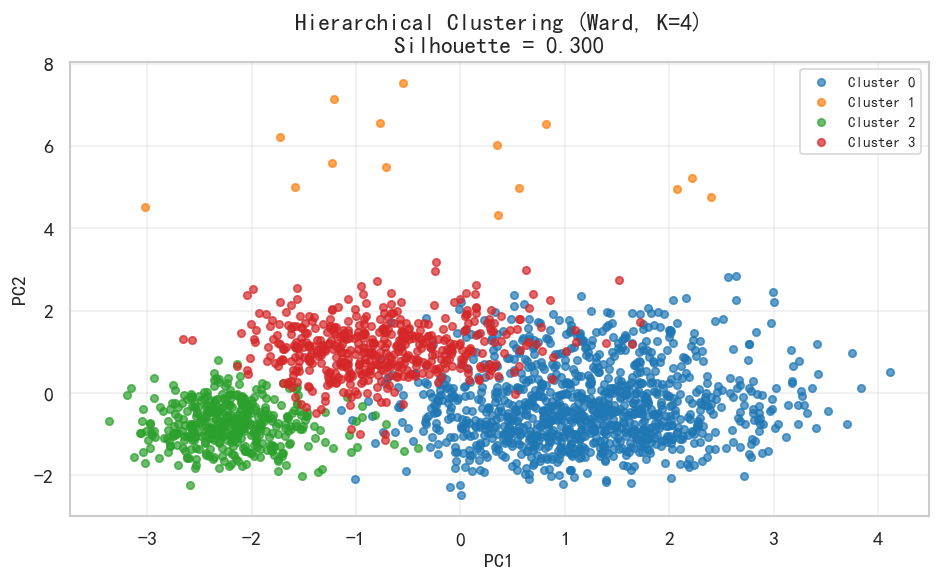

In [26]:
# 4.8 层次聚类散点图
fig, ax = plt.subplots(figsize=(8, 5))

for lbl in sorted(set(labels_hier)):
    mask = labels_hier == lbl
    ax.scatter(X_pca_5[mask, 0], X_pca_5[mask, 1],
               c=COLORS['palette'][int(lbl) % len(COLORS['palette'])],
               s=20, alpha=0.7, label=f"Cluster {lbl}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Hierarchical Clustering (Ward, K={K_final_hier})\n"
             f"Silhouette = {silhouette_score(X_pca_5, labels_hier):.3f}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'Hierarchical_Clustering_Scatter.png')
plt.show()

## 5.K-Means vs 层次聚类

In [27]:
# 5.1 K-Means vs 层次聚类 —— 量化指标对比
km_labels = df['Cluster_Labels_K4'].values

sil_km = silhouette_score(X_pca_5, km_labels)
chi_km = calinski_harabasz_score(X_pca_5, km_labels)
dbi_km = davies_bouldin_score(X_pca_5, km_labels)

sil_hc = silhouette_score(X_pca_5, labels_hier)
chi_hc = calinski_harabasz_score(X_pca_5, labels_hier)
dbi_hc = davies_bouldin_score(X_pca_5, labels_hier)

metrics_compare = pd.DataFrame({
    f'K-Means (K=4)':               [sil_km, chi_km, dbi_km],
    f'Hierarchical (K={K_final_hier})': [sil_hc, chi_hc, dbi_hc],
}, index=['Silhouette ↑', 'Calinski-Harabasz ↑', 'Davies-Bouldin ↓'])

print("===== 指标对比：K-Means vs 层次聚类 =====")
display(metrics_compare.round(4))

ari_compare = adjusted_rand_score(km_labels, labels_hier)
print(f"\nARI（K-Means vs HC 标签一致性）: {ari_compare:.4f}")
print("（ARI 接近 1 → 两种方法结论高度一致；接近 0 → 结构差异显著）")

===== 指标对比：K-Means vs 层次聚类 =====


,K-Means (K=4),Hierarchical (K=4)
Silhouette ↑,0.3212,0.3001
Calinski-Harabasz ↑,938.4620,847.2949
Davies-Bouldin ↓,0.9730,0.9676



ARI（K-Means vs HC 标签一致性）: 0.6885
（ARI 接近 1 → 两种方法结论高度一致；接近 0 → 结构差异显著）


In [31]:
# 5.2 簇规模对比 (K=4 统一对比)
km_counts = pd.Series(km_labels).value_counts().sort_index()
km_shares = (km_counts / len(km_labels) * 100).round(1)

hc_counts = pd.Series(labels_hier).value_counts().sort_index()
hc_shares = (hc_counts / len(labels_hier) * 100).round(1)

compare_size_df = pd.DataFrame({
    'K-Means (n)': km_counts.values,
    'K-Means (%)': km_shares.values,
    'Hierarchical (n)': hc_counts.values,
    'Hierarchical (%)': hc_shares.values
}, index=[f'Cluster {i}' for i in range(4)])

print("===== K=4 聚类算法规模对比 (K-Means vs Hierarchical) =====")
display(compare_size_df)

===== K=4 聚类算法规模对比 (K-Means vs Hierarchical) =====


,K-Means (n),K-Means (%),Hierarchical (n),Hierarchical (%)
Cluster 0,628,31.4,1076,53.8
Cluster 1,466,23.3,15,0.8
Cluster 2,891,44.6,415,20.8
Cluster 3,15,0.8,494,24.7


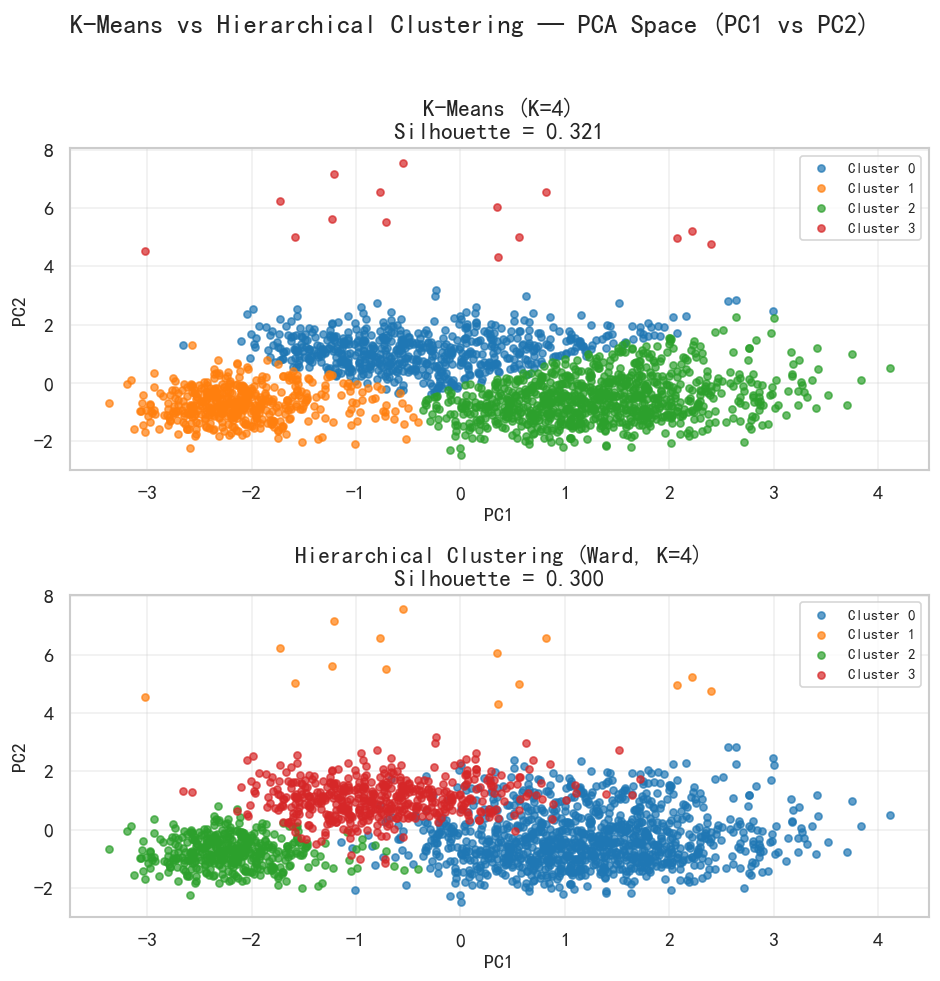

In [32]:
# 5.3 可视化对比散点图
fig, axes = plt.subplots(2,1, figsize=(8,8))

# --- K-Means ---
ax1 = axes[0]
for lbl in sorted(set(km_labels)):
    mask = km_labels == lbl
    ax1.scatter(X_pca_5[mask, 0], X_pca_5[mask, 1],
                c=COLORS['palette'][int(lbl) % len(COLORS['palette'])],
                s=18, alpha=0.7, label=f"Cluster {lbl}")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title(f"K-Means (K=4)\nSilhouette = {sil_km:.3f}",fontweight='bold',fontsize=14)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- 层次聚类 ---
ax2 = axes[1]
for lbl in sorted(set(labels_hier)):
    mask = labels_hier == lbl
    ax2.scatter(X_pca_5[mask, 0], X_pca_5[mask, 1],
                c=COLORS['palette'][int(lbl) % len(COLORS['palette'])],
                s=18, alpha=0.7, label=f"Cluster {lbl}")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title(f"Hierarchical Clustering (Ward, K={K_final_hier})\nSilhouette = {sil_hc:.3f}",fontweight='bold',fontsize=14)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("K-Means vs Hierarchical Clustering — PCA Space (PC1 vs PC2)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hierarchical_vs_kmeans_scatter.png")
plt.show()

## 6.客户画像

===== 数值型画像特征均值 =====


,n,share(%),spend_grocery,spend_fashion,spend_electronics,spend_dining,spend_online,visits_store_per_month,visits_online_per_month,monthly_income,age,num_children,loyalty_score
Cluster_Labels_K4,,,,,,,,,,,,,
0,628,31.4,990.92,444.27,586.68,716.80,526.11,5.98,6.29,11009.79,40.73,1.39,49.18
1,466,23.3,629.18,228.22,263.11,321.24,277.18,2.89,3.51,4559.67,38.05,0.80,35.67
2,891,44.6,528.73,639.17,605.01,657.35,879.28,3.00,12.59,9673.26,31.57,0.37,56.48
3,15,0.8,770.00,496.67,496.67,620.00,646.43,100.00,8.20,7932.14,36.93,0.93,50.53



===== 类别型画像特征（众数及占比）=====


,gender,marital_status,education_level
Cluster_Labels_K4,,,
0,Female (50%),Married (66%),Bachelor (47%)
1,Female (54%),Married (60%),Bachelor (49%)
2,Female (52%),Married (48%),Bachelor (53%)
3,Female (60%),Married (53%),Bachelor (33%)


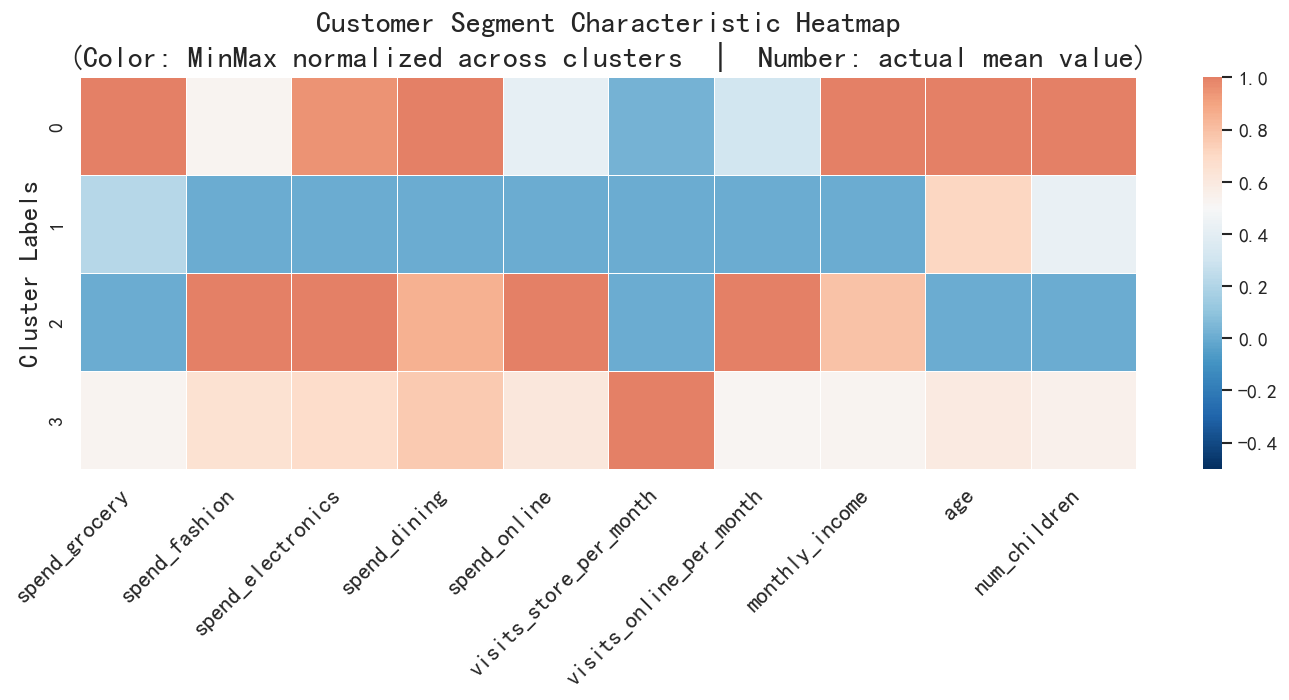


===== 业务验证：各簇平均忠诚度 (loyalty_score) =====


,mean_loyalty,std_loyalty
Cluster_Labels_K4,,
0,49.18,9.82
1,35.67,9.01
2,56.48,10.72
3,50.53,9.75


（忠诚度与消费行为模式一致性越高，说明聚类结果业务有效性越强）


In [33]:
numeric_profile_cols = (
    distanceFeatures
    + ['monthly_income', 'age', 'num_children','loyalty_score']
)
portrait_num = df.groupby('Cluster_Labels_K4')[numeric_profile_cols].mean().round(2)
portrait_num.insert(0, 'n', df.groupby('Cluster_Labels_K4').size())
portrait_num.insert(1, 'share(%)', (portrait_num['n'] / len(df) * 100).round(1))

print("===== 数值型画像特征均值 =====")
display(portrait_num)

cat_cols = ['gender', 'marital_status', 'education_level']

cat_rows = []
for cluster_id, group in df.groupby('Cluster_Labels_K4'):
    row = {'Cluster_Labels_K4': cluster_id}
    for col in cat_cols:
        mode_val = group[col].mode()[0]
        mode_pct = (group[col] == mode_val).mean() * 100
        row[col] = f"{mode_val} ({mode_pct:.0f}%)"
    cat_rows.append(row)

portrait_cat = pd.DataFrame(cat_rows).set_index('Cluster_Labels_K4')
print("\n===== 类别型画像特征（众数及占比）=====")
display(portrait_cat)


heatmap_cols = distanceFeatures + ['monthly_income', 'age', 'num_children']

portrait_heatmap = df.groupby('Cluster_Labels_K4')[heatmap_cols].mean()

# MinMax归一化
col_min   = portrait_heatmap.min()
col_max   = portrait_heatmap.max()
col_range = col_max - col_min

def minmax_col(col):
    rng = col.max() - col.min()
    if rng == 0:
        return pd.Series(0.5, index=col.index)  
    return (col - col.min()) / rng

portrait_minmax = portrait_heatmap.apply(minmax_col)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    portrait_minmax,
    annot=False,   
    fmt='',
    cmap='RdBu_r',
    center=0.5,
    vmin=-0.5, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title(
    "Customer Segment Characteristic Heatmap\n"
    "(Color: MinMax normalized across clusters  |  Number: actual mean value)",
    fontsize=18, fontweight='bold'
)
ax.set_xlabel("")
ax.set_ylabel("Cluster Labels", fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'customer_portrait_heatmap.png')
plt.show()


print("\n===== 业务验证：各簇平均忠诚度 (loyalty_score) =====")
loyalty_valid = df.groupby('Cluster_Labels_K4')['loyalty_score'].agg(
    ['mean', 'std']
).round(2)
loyalty_valid.columns = ['mean_loyalty', 'std_loyalty']
display(loyalty_valid)
print("（忠诚度与消费行为模式一致性越高，说明聚类结果业务有效性越强）")